# 2. Data Preparation & Transforms

**Goal:** Analyze class imbalance in the original dataset, merge duplicate
classes, select the top 4 dominant classes for training, and create balanced
data splits.

---

### Table of Contents

1. [Data Partitioning Strategy](#2.1-Data-Partitioning-Strategy)
2. [Class Distribution & Selection](#2.2-Class-Distribution-&-Selection)
3. [Create Filtered Splits](#2.3-Create-Filtered-Splits)
4. [Fixed Test Set](#2.4-Fixed-Test-Set)
5. [Why No Pixel-Level Transforms](#2.5-Why-No-Pixel-Level-Transforms)
6. [Incremental Datasets](#2.6-Incremental-Datasets)
7. [Verification](#2.7-Verification)

## 2.1 Data Partitioning Strategy

All data subsets are created by `utils/dataset_manager.py`.
The directory structure is:

```
data/
  Tools.v1i.yolov8/               <- Original dataset (NEVER modified)
    train/  (4153 images, 11 classes)
    test/   (1051 images)

  pre_process/
    train/
      bootstrap/   (<= 200 imgs) <- Initial transfer learning
      dataset_1/                  <- Incremental fine-tuning 
      dataset_2/                  <- Incremental fine-tuning
    test/                         <- Fixed evaluation for ALL models
```

**Principles:**
- The original dataset is never modified
- Only the **top 4 classes** are kept after merging duplicates (see analysis below)
- The test set is derived from the original test split
- The same test set is used to evaluate **every** model (bootstrap and fine-tuned)
- Each training stage uses its own training subset

## 2.2 Class Distribution & Selection

The original dataset contains **11 classes**, but the distribution is highly
imbalanced. Additionally, `Pliers` (class 6) and `plier` (class 10) are the
same tool with inconsistent naming.

The following analysis shows the annotation counts, merges the duplicate,
and justifies selecting the **top 4 classes** for training.

In [1]:
import sys
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import yaml

sys.path.insert(0, str(Path.cwd()))
from utils.config import ORIGINAL_DATASET, ORIGINAL_TRAIN_LABELS


Raw class distribution (original training set):
 ID  Class                  Count
-----------------------------------
  0  0                        493
  1  1                        418
  2  Drill                     81
  3  Hammer                  1697
  4  Hardhat                    1
  5  Measuring Tape           149
  6  Pliers                   716
  7  Screwdriver             1483
  8  Toolbox                   73
  9  Wrench                  1582
 10  plier                   1003


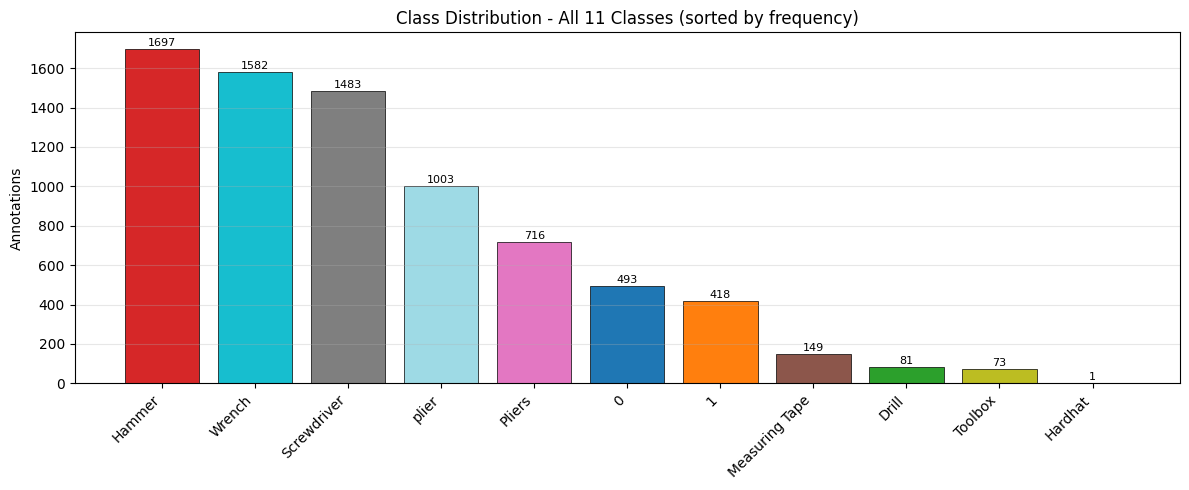


--- Merging duplicate classes ---
  'Pliers' (class 6):  716 annotations
  'plier'  (class 10): 1003 annotations
  Merged 'Pliers':     1719 annotations

Top 4 classes after merge:
  Pliers            1719
  Hammer            1697
  Wrench            1582
  Screwdriver       1483

Top 4 total: 6481 / 7696 (84.2%)
Remaining 7 classes: 1215 (15.8%)

Class filter: {3: 0, 6: 1, 7: 2, 9: 3, 10: 1}
New class names: ['Hammer', 'Pliers', 'Screwdriver', 'Wrench']


In [2]:

# Read all class names from original dataset
with open(ORIGINAL_DATASET / "data.yaml") as f:
    _data_yaml = yaml.safe_load(f)
ALL_CLASS_NAMES = _data_yaml["names"]

# Count annotations per class
counter = Counter()
for lbl in sorted(ORIGINAL_TRAIN_LABELS.glob("*.txt")):
    with open(lbl) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                counter[int(parts[0])] += 1

all_counts = [counter.get(i, 0) for i in range(len(ALL_CLASS_NAMES))]

# --- Raw distribution ---
print("Raw class distribution (original training set):")
print(f"{'ID':>3s}  {'Class':<20s}  {'Count':>6s}")
print("-" * 35)
for i, name in enumerate(ALL_CLASS_NAMES):
    print(f"{i:3d}  {name:<20s}  {all_counts[i]:6d}")

fig, ax = plt.subplots(figsize=(12, 5))
sorted_idx = np.argsort(all_counts)[::-1]
colors = plt.cm.tab20(np.linspace(0, 1, len(ALL_CLASS_NAMES)))
bars = ax.bar(range(len(ALL_CLASS_NAMES)),
              [all_counts[i] for i in sorted_idx],
              color=[colors[i] for i in sorted_idx],
              edgecolor="black", linewidth=0.5)
ax.set_xticks(range(len(ALL_CLASS_NAMES)))
ax.set_xticklabels([ALL_CLASS_NAMES[i] for i in sorted_idx], rotation=45, ha="right")
ax.set_ylabel("Annotations")
ax.set_title("Class Distribution - All 11 Classes (sorted by frequency)")
ax.grid(axis="y", alpha=0.3)
for bar, idx in zip(bars, sorted_idx):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(all_counts[idx]), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

# --- Merge Pliers (6) + plier (10) ---
print("\n--- Merging duplicate classes ---")
print(f"  'Pliers' (class 6):  {counter[6]} annotations")
print(f"  'plier'  (class 10): {counter[10]} annotations")
print(f"  Merged 'Pliers':     {counter[6] + counter[10]} annotations")

merged = {
    "Hammer":      counter[3],
    "Pliers":      counter[6] + counter[10],
    "Screwdriver":  counter[7],
    "Wrench":      counter[9],
}
others_total = sum(all_counts) - sum(merged.values())

print(f"\nTop 4 classes after merge:")
for name, count in sorted(merged.items(), key=lambda x: -x[1]):
    print(f"  {name:<15s}  {count:5d}")
print(f"\nTop 4 total: {sum(merged.values())} / {sum(all_counts)} ({100*sum(merged.values())/sum(all_counts):.1f}%)")
print(f"Remaining 7 classes: {others_total} ({100*others_total/sum(all_counts):.1f}%)")

# Class filter mapping (original_id -> new_id, Pliers+plier both -> 1)
CLASS_FILTER = {3: 0, 6: 1, 7: 2, 9: 3, 10: 1}
print(f"\nClass filter: {CLASS_FILTER}")
print("New class names: ['Hammer', 'Pliers', 'Screwdriver', 'Wrench']")

## 2.3 Create Filtered Splits

The remaining 7 classes have far fewer annotations and would cause severe
class imbalance. Additionally, `Pliers` and `plier` are the same tool with
inconsistent naming in the original dataset.

**Decisions:**
- Merge `Pliers` (class 6) and `plier` (class 10) into a single `Pliers` class
- Keep only the **top 4 classes**: Hammer, Pliers, Screwdriver, Wrench
- Discard the remaining 7 minority classes

**Method:** `utils/dataset_manager.py` with `class_filter`:
- Filters label files to keep only selected classes
- Remaps class IDs to 0–3 (contiguous), merging Pliers + plier into ID 1
- Skips images with no remaining annotations
- Creates bootstrap, incremental splits, and test set

In [3]:
import shutil
from utils.config import PREPROCESSED_DIR, ORIGINAL_DATASET
from utils.dataset_manager import YOLODatasetManager

# Clean previous processed data
if PREPROCESSED_DIR.exists():
    shutil.rmtree(PREPROCESSED_DIR)
    print("Cleaned previous pre_process directory")

# Run filtered split (Pliers + plier both map to new ID 1)
manager = YOLODatasetManager(
    str(ORIGINAL_DATASET),
    str(PREPROCESSED_DIR),
    class_filter=CLASS_FILTER,
)

bootstrap_ids = manager.create_bootstrap(max_images=200)
print(f"Bootstrap: {len(bootstrap_ids)} images")

manager.create_incremental_splits(num_splits=2)
print("Incremental splits created (dataset_1, dataset_2)")

manager.create_test_set()
print("Test set created")

Cleaned previous pre_process directory
Bootstrap: 199 images
Incremental splits created (dataset_1, dataset_2)
Test set created


## 2.4 Fixed Test Set

The test set (`pre_process/test/`) is derived from the original test split,
filtered to keep only the 4 selected classes.

**Rules:**
- It is never modified after creation
- Used to evaluate all models in the pipeline
- Enables fair comparison between bootstrap and fine-tuned models

## 2.5 Why No Pixel-Level Transforms

In a typical computer vision pipeline, common transformations include:
- Resizing
- Pixel normalization
- Data augmentation (flips, rotations, color jitter, etc.)

In this project, **none of these are applied manually**. The reason is that
**YOLOv8 (Ultralytics) handles all of them internally**:

| Transform | Handled by | Detail |
|---|---|---|
| Resize | YOLOv8 | Resizes to `imgsz` (e.g., 640×640) automatically |
| Normalization | YOLOv8 | Scales pixels to [0, 1] internally |
| Mosaic | YOLOv8 | Combines 4 images into one during training |
| Horizontal flip | YOLOv8 | Applied with configurable probability |
| HSV augmentation | YOLOv8 | Color, saturation, and brightness variation |
| Scale / Translate | YOLOv8 | Random scaling and translation |

### Benefits of delegating to the framework

1. **Consistency:** Transforms are applied identically during training and inference
2. **Efficiency:** Applied on-the-fly on GPU, no duplication on disk
3. **Reproducibility:** Controlled by YOLO config, not external scripts
4. **Safety:** Avoids desynchronization between image transforms and bounding box coordinates

## 2.6 Incremental Datasets

`dataset_1` and `dataset_2` will be used in the incremental fine-tuning
stage (Notebook 5). Their purpose is to demonstrate progressive model
improvement by gradually adding training data.

They are not used in the current stages (Notebooks 1–3).

## 2.7 Verification

In [4]:
from utils.config import BOOTSTRAP_DIR, DATASET_1_DIR, DATASET_2_DIR, TEST_DIR, CLASS_NAMES

datasets = {
    "Bootstrap":  BOOTSTRAP_DIR,
    "Dataset 1":  DATASET_1_DIR,
    "Dataset 2":  DATASET_2_DIR,
    "Test":       TEST_DIR,
}

print(f"Selected classes ({len(CLASS_NAMES)}): {CLASS_NAMES}\n")
print(f"{'Subset':<12s}  {'Images':>6s}  {'Labels':>6s}  Path")
print("-" * 70)
for name, path in datasets.items():
    imgs = list((path / "images").glob("*.jpg")) if (path / "images").exists() else []
    lbls = list((path / "labels").glob("*.txt")) if (path / "labels").exists() else []
    print(f"{name:<12s}  {len(imgs):>6d}  {len(lbls):>6d}  {path}")

Selected classes (4): ['Hammer', 'Pliers', 'Screwdriver', 'Wrench']

Subset        Images  Labels  Path
----------------------------------------------------------------------
Bootstrap        199     199  /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/train/bootstrap
Dataset 1       1666    1666  /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/train/dataset_1
Dataset 2       1666    1666  /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/train/dataset_2
Test             893     893  /home/paul/universidad/septimo/IA/final_proyect/notebooks/data/pre_process/test
